In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pyjstat import pyjstat
from sklearn.linear_model import LinearRegression

plt.style.use('seaborn-v0_8-muted')

In [ ]:
url = "https://pxdata.stat.fi/PxWeb/api/v1/en/StatFin/vaerak/statfin_vaerak_pxt_11re.px"

query = {
  "query": [
    { "code": "Alue", "selection": { "filter": "item", "values": ["SSS"] } },
    { "code": "Ikä", "selection": { "filter": "item", "values": ["SSS"] } },
    { "code": "Sukupuoli", "selection": { "filter": "item", "values": ["SSS"] } },
    { "code": "Vuosi", "selection": { "filter": "item", "values": [str(x) for x in range(1972, 2025)] } },
    { "code": "Tiedot", "selection": { "filter": "item", "values": ["vaesto"] } }
  ],
  "response": { "format": "json-stat2" }
}

response = requests.post(url, json=query)
if response.status_code == 200:
    dataset = pyjstat.Dataset.read(response.text)
    df = dataset.write('dataframe')
    df = df.rename(columns={'Year': 'year', 'value': 'population'})
    df['year'] = df['year'].astype(int)
    print("✓ Successfully loaded data from 1972 to 2024")
else:
    print(f"Failed to fetch data. Status: {response.status_code}")

✓ Successfully loaded data from 1972 to 2024


In [ ]:
# Calculate year-over-year growth
df['growth'] = df['population'].diff()

mean_growth = df['growth'].mean()
std_growth = df['growth'].std()
upper_limit = mean_growth + 2 * std_growth

anomalies = df[df['growth'] > upper_limit]

print("\n--- ANOMALY REPORT ---")
print(anomalies[['year', 'growth', 'population']])


--- ANOMALY REPORT ---
    year   growth  population
51  2023  39881.0     5603851


In [ ]:

X = df['year'].values.reshape(-1, 1)
y = df['population'].values

model = LinearRegression()
model.fit(X, y)

future_years = np.arange(2025, 2051).reshape(-1, 1)
predictions = model.predict(future_years)

forecast_df = pd.DataFrame({
    'year': future_years.flatten(),
    'forecast': predictions
})

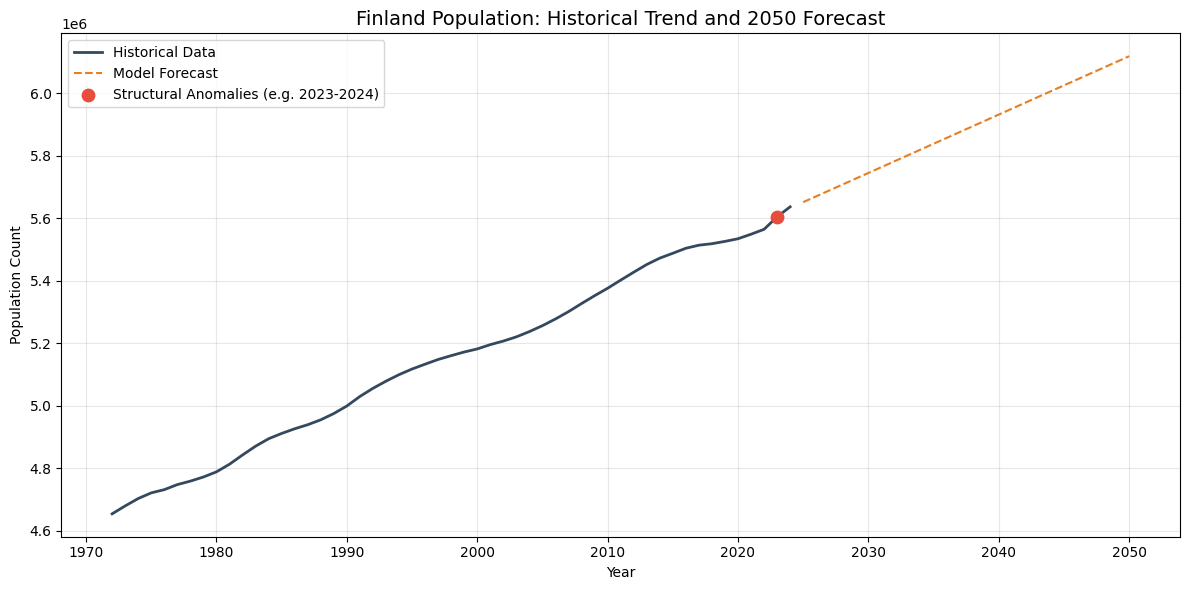

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(df['year'], df['population'], label='Historical Data', color='#34495e', linewidth=2)

plt.plot(forecast_df['year'], forecast_df['forecast'], '--', label='Model Forecast', color='#e67e22')

plt.scatter(anomalies['year'], anomalies['population'], color='#e74c3c', s=80, 
            label='Structural Anomalies (e.g. 2023-2024)', zorder=5)

plt.title('Finland Population: Historical Trend and 2050 Forecast', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Population Count')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

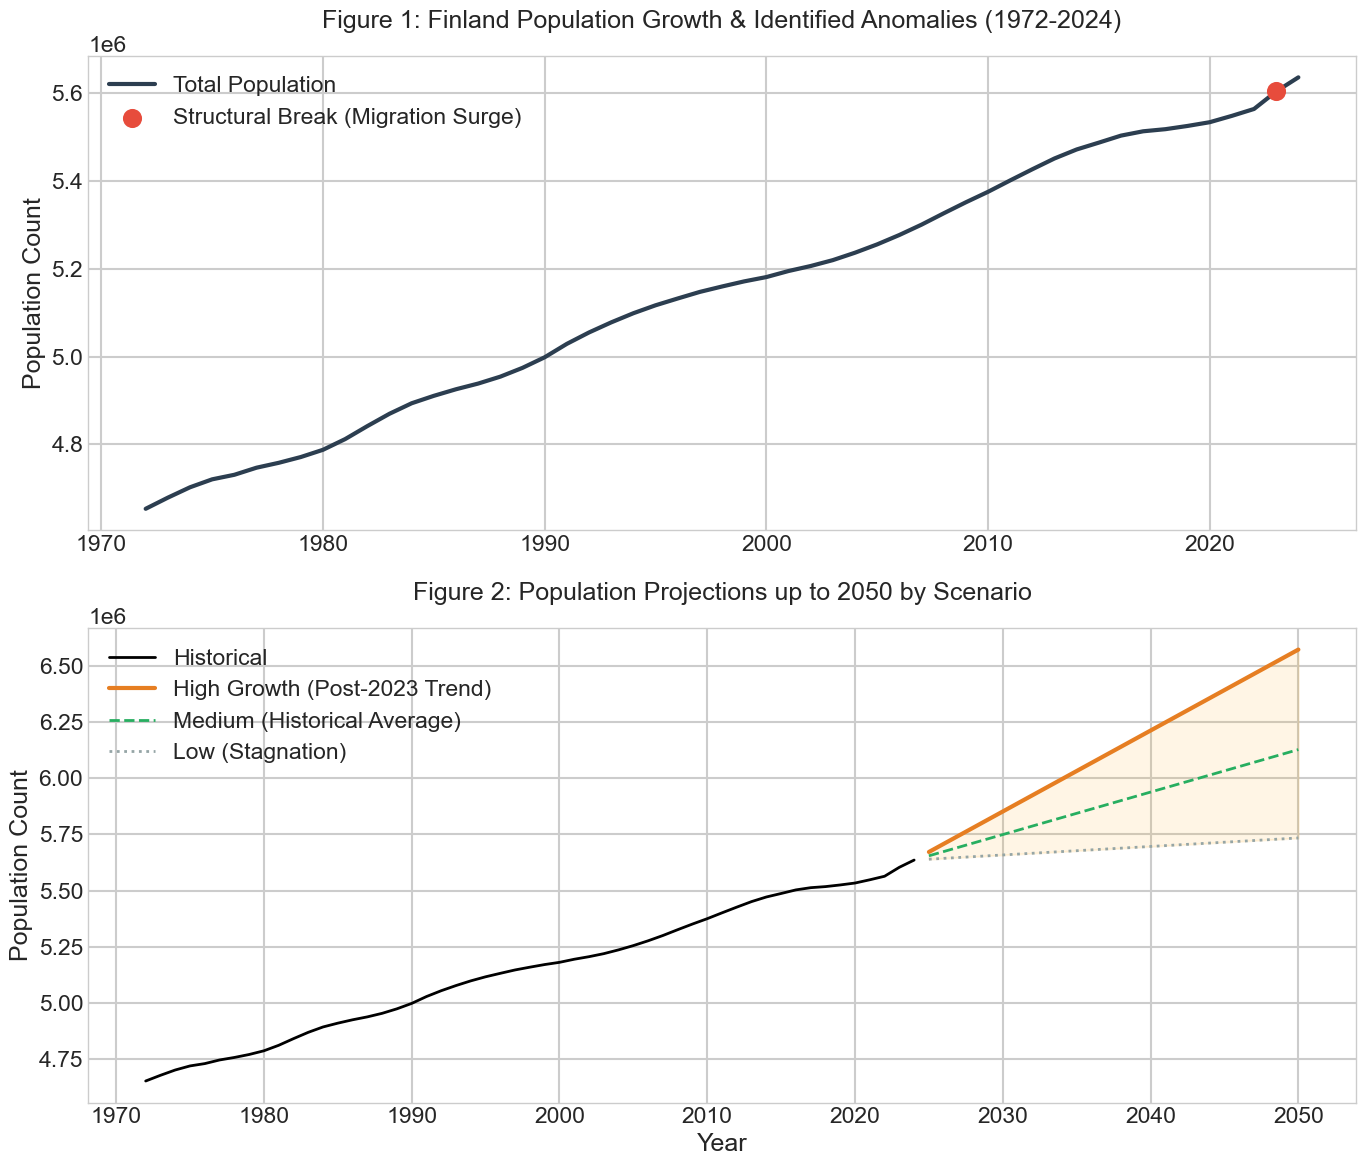

--- 2050 PROJECTIONS ---
Low Scenario: 5,734,228
Trend Scenario: 6,127,256
High (Anomaly) Scenario: 6,571,984


In [ ]:


# Prepare  data
last_year = df['year'].max()
last_pop = df['population'].iloc[-1]
years_future = np.arange(last_year + 1, 2051)
n_years = len(years_future)

avg_growth_hist = df['population'].diff().mean()
recent_growth_anomaly = df['population'].diff().tail(2).mean()

scen_stagnation = last_pop + np.cumsum([avg_growth_hist * 0.2] * n_years)
scen_trend = last_pop + np.cumsum([avg_growth_hist] * n_years)
scen_anomaly = last_pop + np.cumsum([recent_growth_anomaly] * n_years)

# Visualization
# ----------------------------------
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

# Graph. Historical trend and anomalies
ax1.plot(df['year'], df['population'], color='#2c3e50', linewidth=3, label='Total Population')
# Highlight the 'Turning Point' anomalies we found earlier
ax1.scatter(anomalies['year'], anomalies['population'], color='#e74c3c', s=150, 
            label='Structural Break (Migration Surge)', zorder=5)

ax1.set_title('Figure 1: Finland Population Growth & Identified Anomalies (1972-2024)', fontsize=18, pad=20)
ax1.set_ylabel('Population Count')
ax1.legend(loc='upper left')

# Graph. Forecast scenarios to 2050
ax2.plot(df['year'], df['population'], color='black', linewidth=2, label='Historical')
ax2.plot(years_future, scen_anomaly, color='#e67e22', linestyle='-', linewidth=3, label='High Growth (Post-2023 Trend)')
ax2.plot(years_future, scen_trend, color='#27ae60', linestyle='--', linewidth=2, label='Medium (Historical Average)')
ax2.plot(years_future, scen_stagnation, color='#95a5a6', linestyle=':', linewidth=2, label='Low (Stagnation)')

ax2.fill_between(years_future, scen_stagnation, scen_anomaly, color='orange', alpha=0.1)

ax2.set_title('Figure 2: Population Projections up to 2050 by Scenario', fontsize=18, pad=20)
ax2.set_xlabel('Year')
ax2.set_ylabel('Population Count')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

print(f"--- 2050 PROJECTIONS ---")
print(f"Low Scenario: {int(scen_stagnation[-1]):,}")
print(f"Trend Scenario: {int(scen_trend[-1]):,}")
print(f"High (Anomaly) Scenario: {int(scen_anomaly[-1]):,}")